# Final Project

This project conducts a time series analysis to forecast SPY Price. We used the stationary percent change in SPY as a target and used the exogenous variables related to VIX Price and U.S. 10-year Treasury yields to fit an ARIMA model.

## Import

In [1]:
import warnings
warnings.filterwarnings("ignore")
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.simplefilter("ignore", ConvergenceWarning)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import adfuller, grangercausalitytests
from scipy.stats import t
import pandas_datareader.data as web
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
timeSeriesPath = '/content/drive/MyDrive/Time Series Project/Time Series Project Dataset.xlsx'
btcPath = '/content/drive/MyDrive/Time Series Project/Bitcoin_history_data.csv'

daily = pd.read_excel(timeSeriesPath, sheet_name='Daily Data')
monthly = pd.read_excel(timeSeriesPath, sheet_name='Monthly Data')
btc = pd.read_csv(btcPath)

# Fetch 10Y (DGS10) from FRED (percent levels)
use_exog, ust = False, None
try:
    ust = web.DataReader('DGS10', 'fred', daily['Date'].min(), daily['Date'].max()).rename(columns={'DGS10':'UST10Y'})
    ust = ust.reindex(daily['Date']).ffill()
    use_exog = not ust.empty # If DGS10 data available, use exog
except Exception:
    use_exog = False

print(f'FRED DGS10 available: {use_exog}')

FRED DGS10 available: True


In [3]:
daily['Date'] = pd.to_datetime(daily['Date'])
monthly['Month'] = pd.to_datetime(monthly['Month'])
btc['Date'] = pd.to_datetime(btc['Date'])

# Set indices
daily = daily.set_index('Date').sort_index()
monthly = monthly.set_index('Month').sort_index()
btc = (btc.set_index('Date').sort_index())

# Merge Monthly → Daily
monthly_as_daily = monthly.reindex(daily.index, method='ffill')
merged = (daily.join(btc, how='left').join(monthly_as_daily, how='left').join(ust, how='left'))

We made Date the index and then joined using the common index across dataframes. For the monthly data, we transformed it into daily so we can do the join cleanly.

In [4]:
# Create Train Test Split
split_date = merged.index.max() - pd.DateOffset(months=2)
train = merged.loc[:split_date]
test = merged.loc[split_date+pd.Timedelta(days=1):]

print('Train range:', train.index.min(), 'to', train.index.max())
print('Test range:', test.index.min(), 'to', test.index.max())

Train range: 2015-09-08 00:00:00 to 2025-07-03 00:00:00
Test range: 2025-07-07 00:00:00 to 2025-09-05 00:00:00


We want to forecast the last two months of the dataset, so used everything before the last two months as training and the last two months as testing.

## Exploratory Data Analysis

In [5]:
# Drop null leading value for easy usage
returns = train['% Change'].dropna()

We will use % Change in SPY as the return value for time series analysis.

(array([16436., 16801., 17167., 17532., 17897., 18262., 18628., 18993.,
        19358., 19723., 20089.]),
 [Text(16436.0, 0, '2015'),
  Text(16801.0, 0, '2016'),
  Text(17167.0, 0, '2017'),
  Text(17532.0, 0, '2018'),
  Text(17897.0, 0, '2019'),
  Text(18262.0, 0, '2020'),
  Text(18628.0, 0, '2021'),
  Text(18993.0, 0, '2022'),
  Text(19358.0, 0, '2023'),
  Text(19723.0, 0, '2024'),
  Text(20089.0, 0, '2025')])

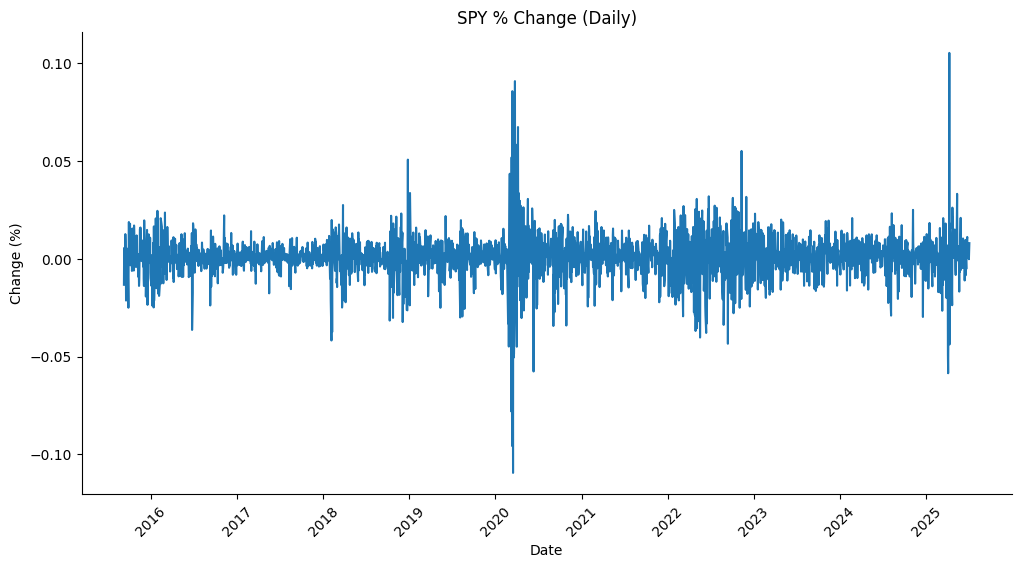

In [6]:
# Plot returns
plt.figure(figsize=(12, 6))
plt.plot(returns)
plt.title('SPY % Change (Daily)')
plt.xlabel('Date')
plt.ylabel('Change (%)')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.xticks(rotation=45)

In [7]:
# ---- ADF Test ----
adf_result = adfuller(returns)
print('ADF Statistic:', adf_result[0])
print('p-value:', adf_result[1])

for key, value in adf_result[4].items():
    print('Critical Value (%s): %.3f' % (key, value))

if adf_result[1] < 0.05:
    print('✅ Stationary (reject null)')
else:
    print('⚠️ Non-stationary (consider differencing)')

ADF Statistic: -15.939930218149396
p-value: 7.560830784823957e-29
Critical Value (1%): -3.433
Critical Value (5%): -2.863
Critical Value (10%): -2.567
✅ Stationary (reject null)


This graph suggests that the returns are stationary and good for time series. The ADF (Augmented Dickey-Fuller) test confirms stationary status for the returns.

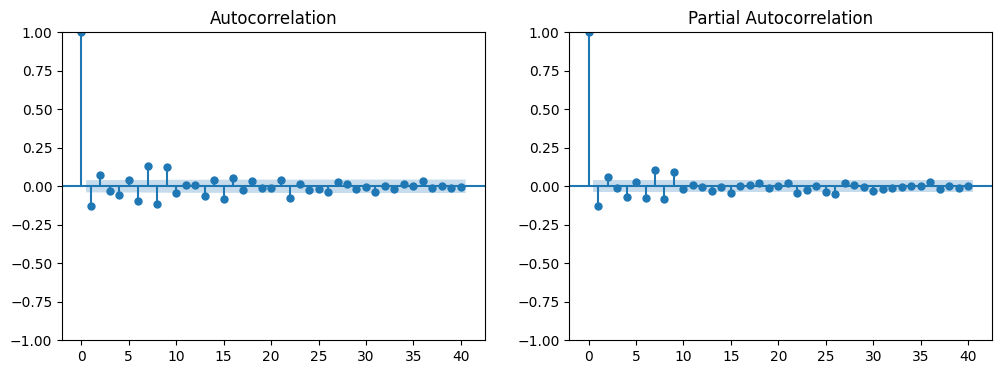

In [8]:
# ---- ACF/PACF Plots ----
fig, axes = plt.subplots(1, 2, figsize=(12,4))
plot_acf(returns, lags=40, ax=axes[0])
plot_pacf(returns, lags=40, ax=axes[1])
plt.show()

These plots indicate that it may be wise to use particular p and q terms in the ARIMA. Seems like there is autocorrelation/partial autocorrelation, so low order paramters will be best (1, 0, 1).

In [9]:
# Granger Causality Test
granger_df = train.copy()
granger_df['VIX Return'] = np.log(granger_df['VIX Price']).diff()
granger_df['UST10Y Return'] = granger_df['UST10Y'].diff().mul(100)
granger_df['BTC Return'] = np.log(granger_df['Close']).diff()
print('---VIX---')
grangercausalitytests(granger_df[['% Change', 'VIX Return']].dropna(), maxlag=5)
print('---UST10Y---')
grangercausalitytests(granger_df[['% Change', 'UST10Y Return']].dropna(), maxlag=5)
print('---BTC---')
grangercausalitytests(granger_df[['% Change', 'BTC Return']].dropna(), maxlag=5)

---VIX---

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=11.9206 , p=0.0006  , df_denom=2465, df_num=1
ssr based chi2 test:   chi2=11.9351 , p=0.0006  , df=1
likelihood ratio test: chi2=11.9063 , p=0.0006  , df=1
parameter F test:         F=11.9206 , p=0.0006  , df_denom=2465, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=6.0764  , p=0.0023  , df_denom=2462, df_num=2
ssr based chi2 test:   chi2=12.1775 , p=0.0023  , df=2
likelihood ratio test: chi2=12.1475 , p=0.0023  , df=2
parameter F test:         F=6.0764  , p=0.0023  , df_denom=2462, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=5.2519  , p=0.0013  , df_denom=2459, df_num=3
ssr based chi2 test:   chi2=15.8005 , p=0.0012  , df=3
likelihood ratio test: chi2=15.7501 , p=0.0013  , df=3
parameter F test:         F=5.2519  , p=0.0013  , df_denom=2459, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=5.37

{np.int64(1): ({'ssr_ftest': (np.float64(0.07007056567610312),
    np.float64(0.7912561954965494),
    np.float64(2465.0),
    np.int64(1)),
   'ssr_chi2test': (np.float64(0.07015584425501926),
    np.float64(0.791110006185562),
    np.int64(1)),
   'lrtest': (np.float64(0.07015484714065678),
    np.float64(0.7911114562610573),
    np.int64(1)),
   'params_ftest': (np.float64(0.0700705656768152),
    np.float64(0.7912561954953546),
    np.float64(2465.0),
    1.0)},
   array([[0., 1., 0.]])]),
 np.int64(2): ({'ssr_ftest': (np.float64(3.4253137541939966),
    np.float64(0.032694218205674044),
    np.float64(2462.0),
    np.int64(2)),
   'ssr_chi2test': (np.float64(6.864540236877815),
    np.float64(0.03231350197040702),
    np.int64(2)),
   'lrtest': (np.float64(6.855007467907853),
    np.float64(0.03246788818459803),
    np.int64(2)),
   'params_ftest': (np.float64(3.4253137541939793),
    np.float64(0.032694218205674044),
    np.float64(2462.0),
    2.0)},
   array([[0., 0., 1., 0., 0

VIX (at all lags) and Treasury (at lag 4) returns seem to predict SPY returns since they have significant p-values. BTC has a significant p-value at lag 2, but otherwise has insignificant p-values. Unlike VIX and Treasuries, BTC has little to no theoretical backing for being connected to SPY Price and its Granger causality test was underwhelming, so we decided to not utilize it for modelling.

## Baseline Model

In [10]:
# --- y_train, y_test are already defined (SPY Price) ---
# Fit ARIMA (no exogenous)
arima_model = SARIMAX(returns, order=(1,0,1))
arima_res = arima_model.fit(disp=False)
print(arima_res.summary())

# Forecast for test horizon
n_forecast = len(test)
arima_forecast = arima_res.get_forecast(steps=n_forecast)
y_pred_arima = arima_forecast.predicted_mean
ci_arima = arima_forecast.conf_int()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:               % Change   No. Observations:                 2469
Model:               SARIMAX(1, 0, 1)   Log Likelihood                7537.012
Date:                Mon, 29 Sep 2025   AIC                         -15068.024
Time:                        02:45:39   BIC                         -15050.589
Sample:                             0   HQIC                        -15061.690
                               - 2469                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5361      0.043    -12.574      0.000      -0.620      -0.453
ma.L1          0.4162      0.046      9.082      0.000       0.326       0.506
sigma2         0.0001   1.49e-06     87.724      0.0

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


We trained a simple ARIMA(1, 0, 1) with no exogenous variables for our baseline.

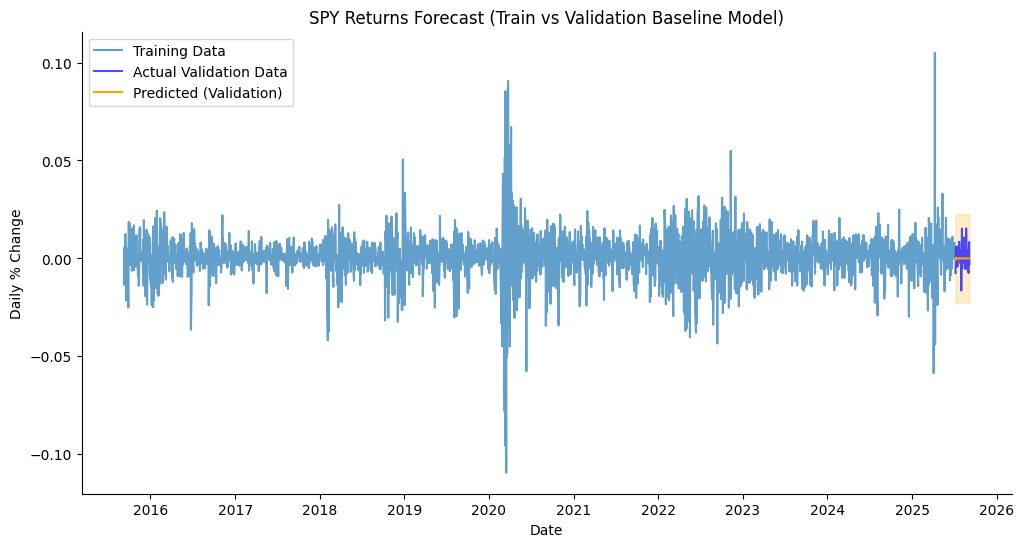

In [11]:
plt.figure(figsize=(12,6))
plt.plot(train.index, train['% Change'], label='Training Data', alpha=0.7)
plt.plot(test.index, test['% Change'], label='Actual Validation Data', color='blue', alpha=0.7)
plt.plot(test.index, arima_forecast.predicted_mean, label='Predicted (Validation)', color='orange')
plt.title('SPY Returns Forecast (Train vs Validation Baseline Model)')
plt.xlabel('Date')
plt.ylabel('Daily % Change')
plt.legend()
plt.fill_between(
    test.index,
    ci_arima['lower % Change'],  # lower bounds
    ci_arima['upper % Change'],  # upper bounds
    color='orange',
    alpha=0.2,
    label='Confidence Interval'
)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.show()

The forecast looks flat for the returns of SPY for the baseline model, indicating small amounts of nuance were understood.

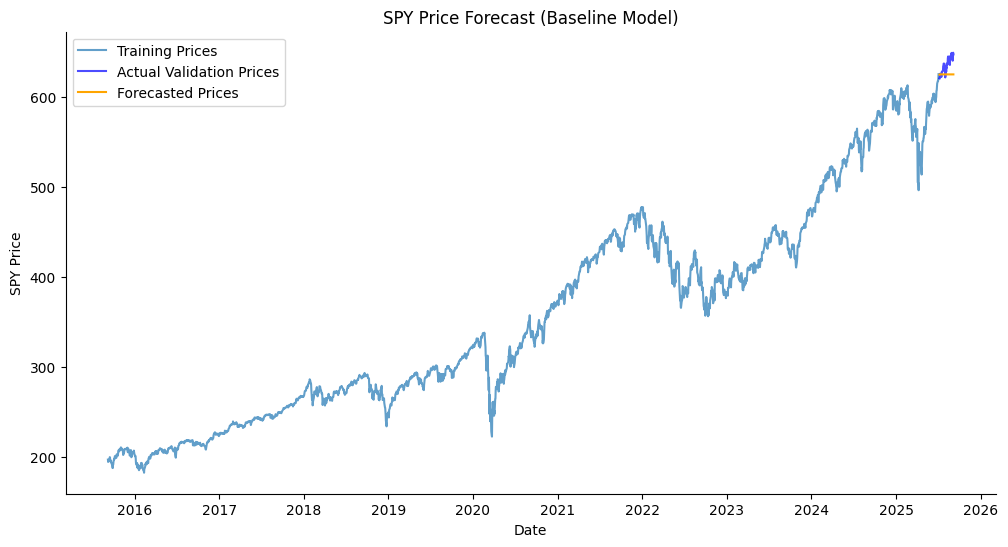

In [12]:
# Price performance
last_train_price = train['SPY Price'].iloc[-1]

# Convert returns forecast into price forecast
price_forecast = last_train_price * (1 + arima_forecast.predicted_mean).cumprod()

# Convert CI bounds into prices (apply same cumulative transform)
price_conf_int_lower = last_train_price * (1 + ci_arima['lower % Change']).cumprod()
price_conf_int_upper = last_train_price * (1 + ci_arima['upper % Change']).cumprod()

# Actual validation prices
actual_prices = test['SPY Price']

plt.figure(figsize=(12,6))
plt.plot(train.index, train['SPY Price'], label='Training Prices', alpha=0.7)
plt.plot(test.index, actual_prices, label='Actual Validation Prices', color='blue', alpha=0.7)
plt.plot(test.index, price_forecast, label='Forecasted Prices', color='orange')
plt.title('SPY Price Forecast (Baseline Model)')
plt.xlabel('Date')
plt.ylabel('SPY Price')
plt.legend()

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.show()

Forecast is very flat for prices as well. It seems to not picked up trends too well. It is guess in the right area, but not making smart decisions on what will happen next.

In [13]:
y_pred = price_forecast
y_true = actual_prices

mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_true, y_pred)

print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)

MSE : 174.90471921650604
RMSE: 13.225154789888322
MAE : 10.998209513963156


These test statistics are quite good. The model is not missing by much (but it is also not doing much to guess what will happen and is assuming things will remain similar for the forecast).

In [14]:
lb_test = acorr_ljungbox(arima_res.resid, lags=10, return_df=True)
display(lb_test.round(5))

,lb_stat,lb_pvalue
1,0.07111,0.78973
2,0.46821,0.79128
3,0.52675,0.91298
4,11.02634,0.02627
5,11.98841,0.03495
6,23.71819,0.00059
7,50.69174,0.00000
8,66.70729,0.00000
9,92.29973,0.00000
10,93.59427,0.00000


Some signficant p-values here, indicating there is significant autocorrelation with the residuals. That fails the Ljung–Box test after lag 3.

## Final Model

In [15]:
# Build TRAINING exog (only if DGS10 available)
# VIX_ret_l1  = lag1 log-return of VIX
# UST10Y_dbp_l4 = lag4 daily change of 10Y in basis points
if use_exog:
    # Training exogenous variable set
    vix_aligned = train['VIX Price']
    vix_ret = np.log(vix_aligned).diff()
    ust_dbp = train['UST10Y'].diff().mul(100)
    X_train = pd.DataFrame({
        'VIX_ret_l1': vix_ret.shift(1),
        'UST10Y_dbp_l4': ust_dbp.shift(4)
    }, index=train.index).dropna()
    y_train = train['% Change'].reindex(X_train.index)

    # Testing exogenous variable set
    vix_aligned = test['VIX Price']
    vix_ret = np.log(vix_aligned).diff()
    ust_dbp = test['UST10Y'].diff().mul(100)
    btc_ret = np.log(test['Close']).diff()
    X_test = pd.DataFrame({
        'VIX_ret_l1': vix_ret.shift(1),
        'UST10Y_dbp_l4': ust_dbp.shift(4)
    }, index=test.index).dropna()
    y_test = test['% Change'].reindex(X_test.index)
else:
    X_train = None
    y_train = train['% Change']

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/p


Forecast preview:
               Point  PI80_Lower  PI80_Upper  PI95_Lower  PI95_Upper
Date                                                                
2025-07-14  0.000288   -0.014360    0.014935   -0.022114    0.022689
2025-07-15  0.001782   -0.012922    0.016485   -0.020705    0.024269
2025-07-16  0.000404   -0.014322    0.015130   -0.022118    0.022926
2025-07-17 -0.000034   -0.014770    0.014701   -0.022571    0.022502
2025-07-18  0.000242   -0.014498    0.014982   -0.022301    0.022784


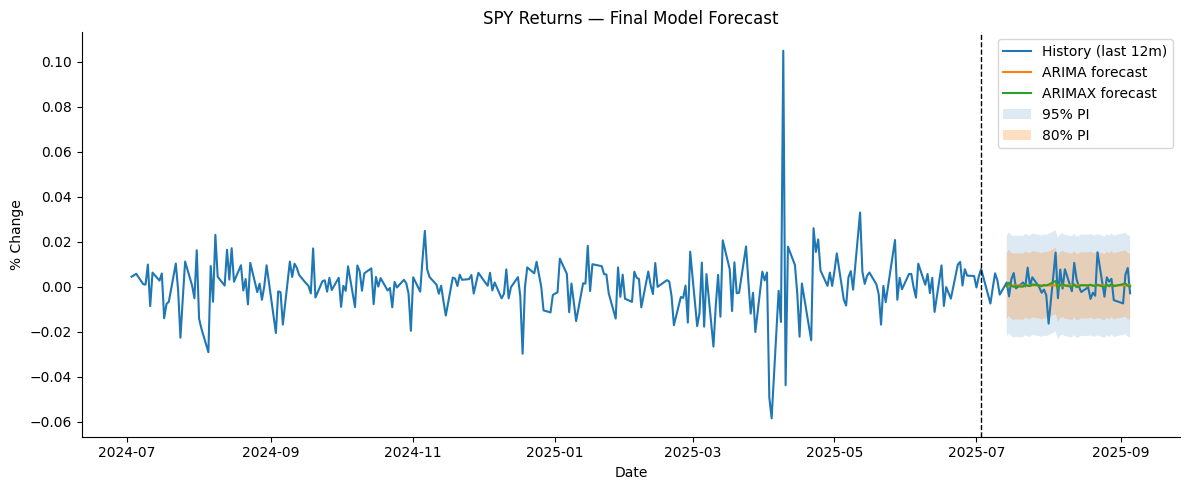

In [16]:
# Final FORECAST
## NOTE: This (final_model) is the final model which we will enter for the contest!!!

final_model = SARIMAX(y_train, order=(1, 0, 1), trend='t', exog=X_train if use_exog else None,
                        enforce_stationarity=False, enforce_invertibility=False
                        ).fit(method='lbfgs', maxiter=200, disp=False)

fc = final_model.get_forecast(steps=len(y_test), exog=X_test)
pred = fc.predicted_mean
ci80 = fc.conf_int(alpha=0.20)
ci95 = fc.conf_int(alpha=0.05)

# Get confidence intervals
forecast_df = pd.DataFrame({
    'Point'      : pred.to_numpy(),
    'PI80_Lower' : ci80.iloc[:,0].to_numpy(),
    'PI80_Upper' : ci80.iloc[:,1].to_numpy(),
    'PI95_Lower' : ci95.iloc[:,0].to_numpy(),
    'PI95_Upper' : ci95.iloc[:,1].to_numpy(),
}, index=X_test.index)

# Baseline ARIMA overlay line (trained on y_train only)
base_model = SARIMAX(y_train, order=(1, 0, 1), trend='t',
                     enforce_stationarity=False, enforce_invertibility=False
                    ).fit(method='lbfgs', maxiter=200, disp=False)
base_fc = base_model.get_forecast(steps=len(X_test.index))
base_df = pd.DataFrame({'Point': base_fc.predicted_mean.to_numpy()}, index=X_test.index)

# For a cleaner chart, show last 12 months only
hist_start = y_train.index.max() - pd.DateOffset(months=12)

print('\nForecast preview:')
print(forecast_df.head())

plt.figure(figsize=(12,5))
plt.plot(merged.loc[hist_start:merged.index.max(), '% Change'], label='History (last 12m)')
plt.plot(base_df.index, base_df['Point'], label='ARIMA forecast')
plt.plot(forecast_df.index, forecast_df['Point'],
         label=('ARIMAX forecast' if use_exog else 'ARIMA (final)'))
plt.fill_between(forecast_df.index, forecast_df['PI95_Lower'], forecast_df['PI95_Upper'],
                 alpha=0.15, label='95% PI')
plt.fill_between(forecast_df.index, forecast_df['PI80_Lower'], forecast_df['PI80_Upper'],
                 alpha=0.25, label='80% PI')
plt.axvline(y_train.index.max(), linestyle='--', linewidth=1, color='k')
plt.title('SPY Returns — Final Model Forecast')
plt.xlabel('Date'); plt.ylabel('% Change'); plt.legend()
plt.tight_layout()
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.show()

Forecast of returns for final model

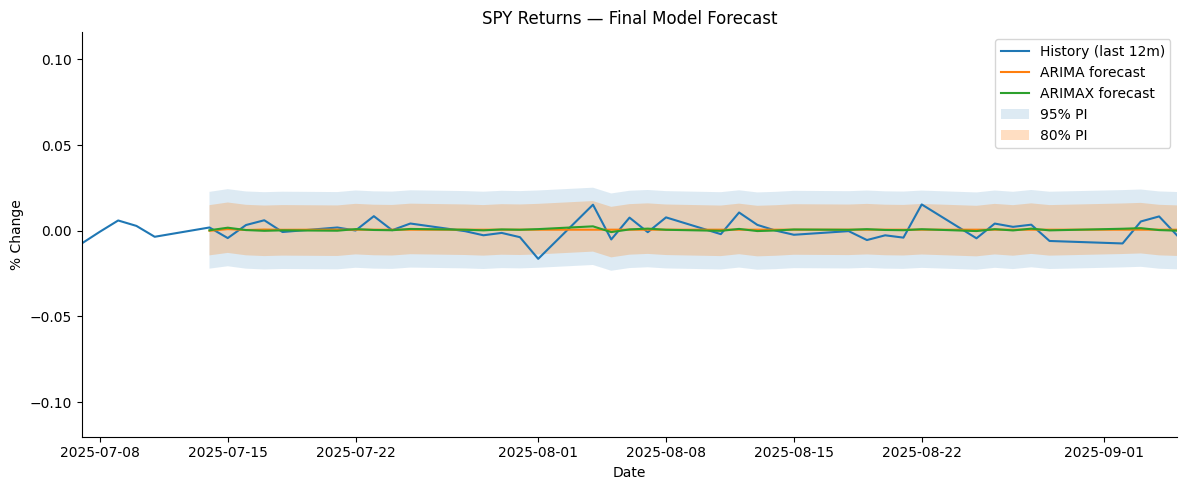

In [17]:
plt.figure(figsize=(12,5))
plt.plot(merged.index, merged['% Change'], label='History (last 12m)')
plt.plot(base_df.index, base_df['Point'], label='ARIMA forecast')
plt.plot(forecast_df.index, forecast_df['Point'],
         label=('ARIMAX forecast' if use_exog else 'ARIMA (final)'))
plt.fill_between(forecast_df.index, forecast_df['PI95_Lower'], forecast_df['PI95_Upper'],
                 alpha=0.15, label='95% PI')
plt.fill_between(forecast_df.index, forecast_df['PI80_Lower'], forecast_df['PI80_Upper'],
                 alpha=0.25, label='80% PI')
plt.axvline(y_train.index.max(), linestyle='--', linewidth=1, color='k')
plt.title('SPY Returns — Final Model Forecast')
plt.xlabel('Date'); plt.ylabel('% Change'); plt.legend()
plt.tight_layout()
plt.xlim(test.index.min(), test.index.max())
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.show()

This zoomed in view shows that the returns are fairly stagnant and so is the forecast. The ARIMAX has a bit more movement than the ARIMA, but both do not catch the very subtle changes in the actual data.  

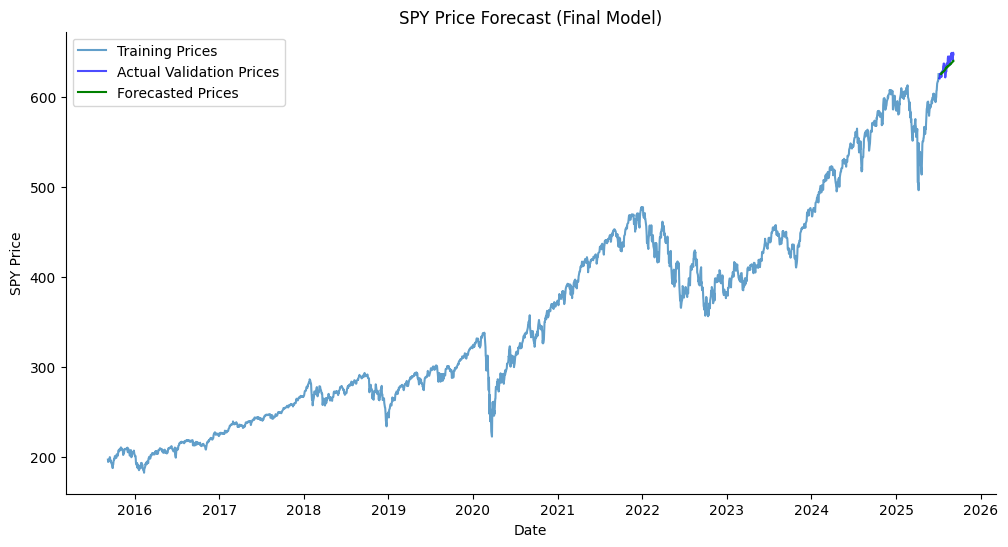

In [18]:
# Price performance forecast
last_train_price = train['SPY Price'].iloc[-1]

# Convert returns forecast into price forecast
price_forecast = last_train_price * (1 + pred).cumprod()

# Actual validation prices
plt.figure(figsize=(12,6))
plt.plot(train.index, train['SPY Price'], label='Training Prices', alpha=0.7)
plt.plot(test.index, test['SPY Price'], label='Actual Validation Prices', color='blue', alpha=0.7)
plt.plot(X_test.index, price_forecast, label='Forecasted Prices', color='green')
plt.title('SPY Price Forecast (Final Model)')
plt.xlabel('Date')
plt.ylabel('SPY Price')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.legend()
plt.show()

Price forecast derived from model of returns

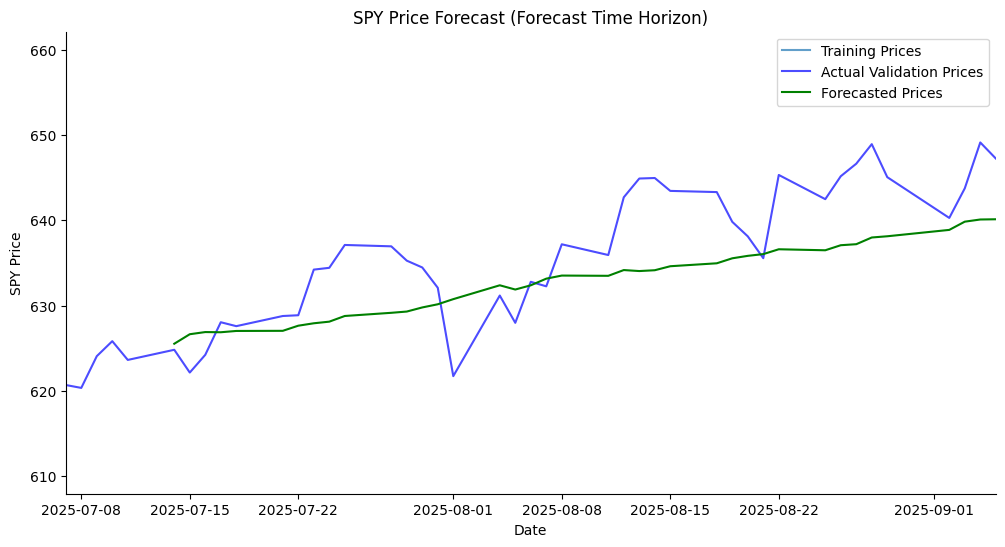

In [19]:
# Actual validation prices
plt.figure(figsize=(12,6))
plt.plot(train.index, train['SPY Price'], label='Training Prices', alpha=0.7)
plt.plot(test.index, test['SPY Price'], label='Actual Validation Prices', color='blue', alpha=0.7)
plt.plot(X_test.index, price_forecast, label='Forecasted Prices', color='green')
plt.title('SPY Price Forecast (Forecast Time Horizon)')
plt.xlabel('Date')
plt.ylabel('SPY Price')
plt.legend()
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.xlim(test.index.min(), test.index.max())
plt.ylim(
    test['SPY Price'].min() * 0.98,
    test['SPY Price'].max() * 1.02
)
plt.show()

Zoomed in forecast of price

With the price view, we can see the ARIMAX is understanding the prices often goes up over time (which is historically accurate). It has small wiggles on daily prices, but is best at catching the general trend over time.

### Final Model Evaluation

In [20]:
summary = final_model.summary()

print(summary)

                               SARIMAX Results                                
Dep. Variable:               % Change   No. Observations:                 2465
Model:               SARIMAX(1, 0, 1)   Log Likelihood                7511.458
Date:                Mon, 29 Sep 2025   AIC                         -15010.917
Time:                        02:45:48   BIC                         -14976.062
Sample:                             0   HQIC                        -14998.253
                               - 2465                                         
Covariance Type:                  opg                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
drift          3.811e-07   2.47e-07      1.546      0.122   -1.02e-07    8.64e-07
VIX_ret_l1        0.0070      0.003      2.410      0.016       0.001       0.013
UST10Y_dbp_l4 -7.795e-05   2.72e-05     

Very similar AIC to baseline, but much more complexity.

In [21]:
# Extract coefficients table
coefs = summary.tables[1]
coef_df = pd.DataFrame(coefs.data[1:], columns=coefs.data[0])
coef_df.columns = ["Variable", "Coef", "Std Err", "z", "P>|z|", "[0.025", "0.975]"]

for col in ["Coef", "Std Err", "z", "P>|z|", "[0.025", "0.975]"]:
    coef_df[col] = pd.to_numeric(coef_df[col], errors="coerce")

coef_df["Significant"] = coef_df["P>|z|"] < 0.05

print("\n=== Coefficients (significant ones marked) ===")
print(coef_df.to_string(index=False))


=== Coefficients (significant ones marked) ===
     Variable          Coef      Std Err       z  P>|z|        [0.025        0.975]  Significant
        drift  3.811000e-07 2.470000e-07   1.546  0.122 -1.020000e-07  8.640000e-07        False
   VIX_ret_l1  7.000000e-03 3.000000e-03   2.410  0.016  1.000000e-03  1.300000e-02         True
UST10Y_dbp_l4 -7.795000e-05 2.720000e-05  -2.866  0.004 -0.000000e+00 -2.460000e-05         True
        ar.L1 -6.414000e-01 4.900000e-02 -13.099  0.000 -7.370000e-01 -5.450000e-01         True
        ma.L1  5.539000e-01 5.600000e-02   9.971  0.000  4.450000e-01  6.630000e-01         True
       sigma2  1.000000e-04 1.620000e-06  80.530  0.000  0.000000e+00  0.000000e+00         True


Our exogenous variables are significant in the model

In [22]:
y_pred = price_forecast
y_true = test['SPY Price'][X_test.index]

mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_true, y_pred)

print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)

MSE : 38.10877645627161
RMSE: 6.173230633652984
MAE : 5.165037052290924


In [23]:
lb_test = acorr_ljungbox(final_model.resid, lags=10, return_df=True)
display(lb_test.round(5))

,lb_stat,lb_pvalue
1,0.06540,0.79816
2,0.95563,0.62014
3,1.07685,0.78266
4,11.59625,0.02062
5,13.27783,0.02091
6,27.61497,0.00011
7,54.30190,0.00000
8,73.44247,0.00000
9,100.36595,0.00000
10,101.92786,0.00000


We failed the test after lag 3!

## Scrap models

These models were left on the cutting room floor

DEBUG:cmdstanpy:input tempfile: /tmp/tmp3tufyo1_/2ter38qu.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3tufyo1_/kqz8drxu.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=81403', 'data', 'file=/tmp/tmp3tufyo1_/2ter38qu.json', 'init=/tmp/tmp3tufyo1_/kqz8drxu.json', 'output', 'file=/tmp/tmp3tufyo1_/prophet_modelfrl8b6tp/prophet_model-20250929024549.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
02:45:49 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
02:45:49 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3tufyo1_/ro4cadl2.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3tufyo1_/4ufha9xf.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/

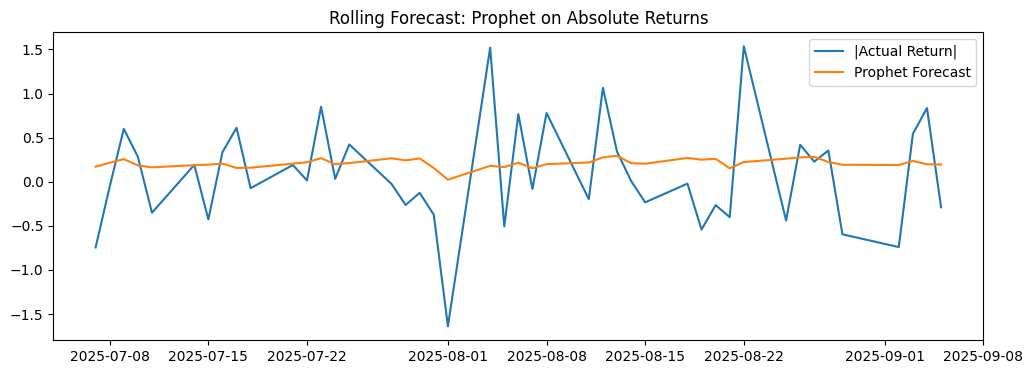

In [24]:
from prophet import Prophet

# Prepare data for Prophet
returns = merged['% Change']
returns_df = merged.reset_index().copy()
returns_df.rename(columns={'Date': 'ds', '% Change': 'y'}, inplace=True)
returns_df = returns_df[['ds', 'y', 'VIX Price', 'Federal Interest Rate (%)']]
returns_df['y'] = returns_df['y'] * 100

rolling_preds = []
true_vals = []
window = len(train) - 1

for i in range(window, len(returns) - 1):
    train_df = returns_df.iloc[:i].copy()
    test_val = returns_df.iloc[i + 1]['y']

    # Fit Prophet model
    model = Prophet(daily_seasonality=False, weekly_seasonality=True, yearly_seasonality=False)
    model.add_regressor('VIX Price')
    model.add_regressor('Federal Interest Rate (%)')
    model.fit(train_df)

    # Make 1-step ahead forecast
    future = pd.DataFrame({'ds': [returns_df.iloc[i + 1]['ds']], 'VIX Price': [returns_df.iloc[i + 1]['VIX Price']], 'Federal Interest Rate (%)': [returns_df.iloc[i + 1]['Federal Interest Rate (%)']]})
    forecast = model.predict(future)

    rolling_preds.append(forecast['yhat'].values[0])
    true_vals.append(test_val)

# Plot
plt.figure(figsize=(12, 4))
plt.plot(returns.index[window + 1:], true_vals, label="|Actual Return|")
plt.plot(returns.index[window + 1:], rolling_preds, label="Prophet Forecast")
plt.legend()
plt.title("Rolling Forecast: Prophet on Absolute Returns")
plt.show()

Train: 2015-09-09 00:00:00 to 2025-07-04 00:00:00 | 2563
Test : 2025-07-07 00:00:00 to 2025-09-05 00:00:00 | 45
                               SARIMAX Results                                
Dep. Variable:                log_spy   No. Observations:                 2563
Model:                 ARIMA(1, 1, 1)   Log Likelihood                7901.671
Date:                Mon, 29 Sep 2025   AIC                         -15795.341
Time:                        02:46:08   BIC                         -15771.947
Sample:                    09-09-2015   HQIC                        -15786.859
                         - 07-04-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
btc_ret        0.0347      0.002     15.189      0.000       0.030       0.039
ar.L1         -0.50

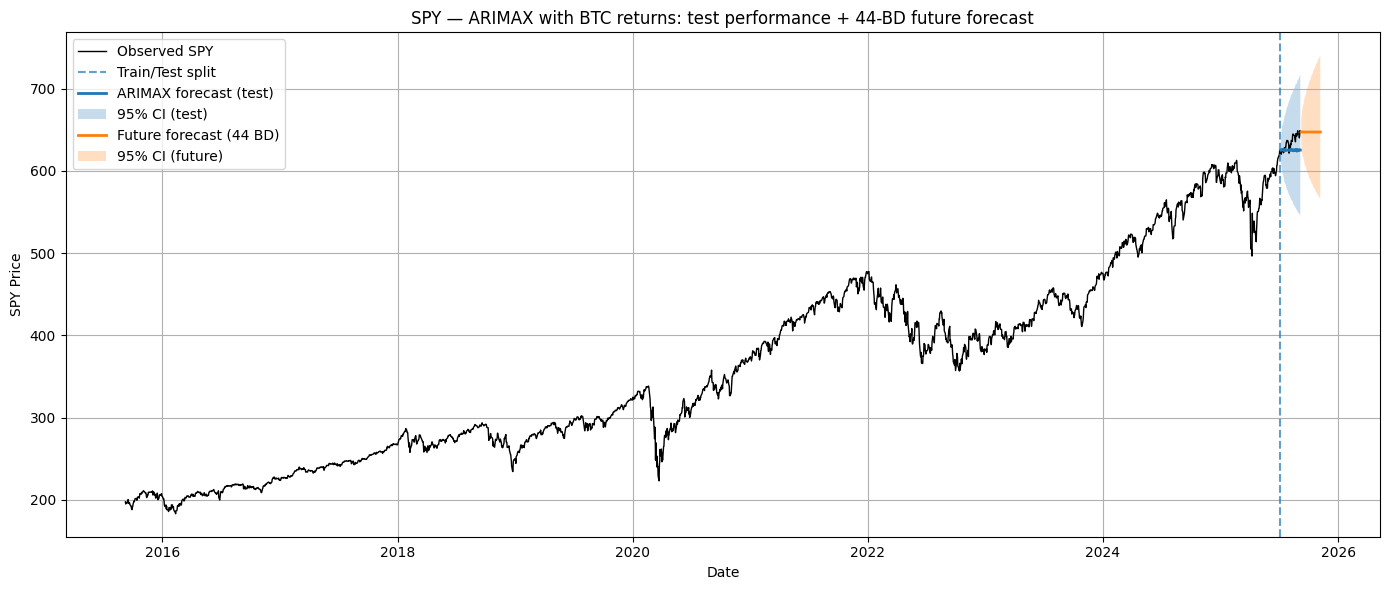

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.tsa.arima.model import ARIMA

# ----------------------------
# Config (edit names if needed)
# ----------------------------
spy_col = 'SPY Price'
btc_col = 'Close'       # Bitcoin closing price
h = 44                 # future forecast horizon (about 2 months)

# ============================
# 1) Build the dataframe for use in the analysis
# ============================
if 'Date' in merged.columns:
    keep = ['Date', spy_col, btc_col]
    missing = [c for c in keep if c not in merged.columns]
    if missing:
        raise ValueError(f"Missing expected columns: {missing}. Available: {list(merged.columns)}")
    df_btc = merged[keep].copy()
    df_btc['Date'] = pd.to_datetime(df_btc['Date'], errors='coerce')
    df_btc = (df_btc.dropna(subset=['Date'])
                     .sort_values('Date')
                     .drop_duplicates('Date')
                     .set_index('Date'))
else:
    # Date already in the index
    for c in [spy_col, btc_col]:
        if c not in merged.columns:
            raise ValueError(f"Missing expected column: {c}. Available: {list(merged.columns)}")
    df_btc = merged[[spy_col, btc_col]].copy()
    df_btc.index = pd.to_datetime(df_btc.index, errors='coerce')
    df_btc = df_btc[~df_btc.index.isna()].sort_index()
    df_btc = df_btc[~df_btc.index.duplicated(keep='last')]

# Align to business days & clean numerics
df_btc = df_btc.asfreq('B')  # business-day grid
eps = 1e-8
for c in [spy_col, btc_col]:
    df_btc[c] = pd.to_numeric(df_btc[c], errors='coerce').clip(lower=eps).ffill().bfill()

# ============================
# 2) Endog/Exog
#    y = log(SPY), X = BTC log-returns
# ============================
log_spy = np.log(df_btc[spy_col])
btc_ret = np.log(df_btc[btc_col]).diff()

aligned = pd.concat([log_spy.rename('log_spy'),
                     btc_ret.rename('btc_ret')], axis=1).dropna()

y = aligned['log_spy']
X = aligned[['btc_ret']]

# ============================
# 3) Train/Test split
# ============================
split_point = (y.index.max() - pd.DateOffset(months=2)).floor('D')
y_train = y.loc[y.index <= split_point]
y_test  = y.loc[y.index >  split_point]
X_train = X.loc[X.index <= split_point]
X_test  = X.loc[X.index >  split_point]

print("Train:", y_train.index.min(), "to", y_train.index.max(), "|", len(y_train))
print("Test :", y_test.index.min(),  "to", y_test.index.max(),  "|", len(y_test))

# ============================
# 4) Fit ARIMAX on TRAIN
# ============================
order = (1, 1, 1)
res = ARIMA(endog=y_train, exog=X_train, order=order).fit()
print(res.summary())

# ============================
# 5) Forecast over TEST horizon
# ============================
n_forecast = len(y_test)
fc_test = res.get_forecast(steps=n_forecast, exog=X_test)

pred_log_test = pd.Series(fc_test.predicted_mean, index=y_test.index)
ci_log_test   = fc_test.conf_int()

# Back-transform to price for eval/plot
pred_test = np.exp(pred_log_test)
ci_lower_test = np.exp(ci_log_test.iloc[:, 0])
ci_upper_test = np.exp(ci_log_test.iloc[:, 1])
actual_test = np.exp(y_test)

mse  = mean_squared_error(actual_test, pred_test)
rmse = float(np.sqrt(mse))
mae  = mean_absolute_error(actual_test, pred_test)
print(f"Test RMSE: {rmse:,.4f} | MAE: {mae:,.4f}")

# ============================
# 6) Refit on FULL data, then 100-BD future forecast
# ============================
res_full = ARIMA(endog=y, exog=X, order=order).fit()

future_idx = pd.bdate_range(df_btc.index.max() + pd.offsets.BusinessDay(), periods=h)

last_btc_ret = float(X.iloc[-1, 0])
X_future = pd.DataFrame({'btc_ret': last_btc_ret}, index=future_idx)

fc_future = res_full.get_forecast(steps=h, exog=X_future)
pred_log_future = pd.Series(fc_future.predicted_mean, index=future_idx)
ci_log_future   = fc_future.conf_int()

price_future     = np.exp(pred_log_future)
ci_lower_future  = np.exp(ci_log_future.iloc[:, 0])
ci_upper_future  = np.exp(ci_log_future.iloc[:, 1])

# Save table
forecast_table = pd.DataFrame({
    'Date': price_future.index,
    'Forecast Price': price_future.round(2),
    'Lower 95% CI': ci_lower_future.round(2),
    'Upper 95% CI': ci_upper_future.round(2)
}).reset_index(drop=True)

print(forecast_table.head(10))
forecast_table.to_csv('spy_100bd_future_forecast.csv', index=False)
print("Saved 100-business-day forecast to spy_44bd_future_forecast.csv")

# ============================
# 7) Plot: history, test forecast, future forecast
# ============================
plt.figure(figsize=(14, 6))
plt.plot(df_btc.index, df_btc[spy_col], label='Observed SPY', color='black', linewidth=1)
plt.axvline(split_point, ls='--', alpha=0.7, label='Train/Test split')

# Test forecast
plt.plot(pred_test.index, pred_test, label='ARIMAX forecast (test)', linewidth=2)
plt.fill_between(pred_test.index, ci_lower_test, ci_upper_test, alpha=0.25, label='95% CI (test)')

# Future forecast
plt.plot(price_future.index, price_future, label='Future forecast (44 BD)', linewidth=2)
plt.fill_between(price_future.index, ci_lower_future, ci_upper_future, alpha=0.25, label='95% CI (future)')

plt.title('SPY — ARIMAX with BTC returns: test performance + 44-BD future forecast')
plt.xlabel('Date')
plt.ylabel('SPY Price')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig("../visuals/forecast_vs_actual.png", dpi=300, bbox_inches="tight")

plt.show()